# **BANK CUSTOMER CHURN ANALYSIS**
**Overview**

Retaining existing customers is often more cost-effective than acquiring new ones. This project analyzes a banking dataset containing information on customers from France, Germany, and Spain to identify why they are leaving the bank (churning).

The goal of this analysis is to uncover the key drivers of churn and provide actionable insights into customer behavior across different demographics.

**Objectives**

Through this analysis, I aim to answer the following business questions:
* What attributes are more common among churners than non-churners?
* Can churn be predicted using the variables in the data?
* What do the overall demographics of the bank's customers look like?
* Is there a difference between German, French, and Spanish customers in terms of account behavior?
* What types of segments exist within the bank's customers?


**Methodology**

To reach these insights, the project is structured into three main phases:
* Data Cleaning & Transformation
* Exploratory Data Analysis (EDA)
* Insight Generation & Visualisation

In [274]:
# Importing needed libraries
import numpy as np

import pandas as pd

from matplotlib import pyplot as plt

import seaborn as sns

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"

### LOAD DATA
* Loading data from excel file
* There are two worksheets in the excel file. So loading both
* Customer_Info sheet is assigned as dataframe 'ci'.
* Account_Info sheet is assigned as dataframe 'ai'.

In [135]:
ci = pd.read_excel('Bank_Churn_Messy.xlsx',sheet_name='Customer_Info')

In [136]:
ai = pd.read_excel('Bank_Churn_Messy.xlsx',sheet_name='Account_Info')

## **DATA INSPECTION**
* Verified that data loaded correctly.
* Checked each columns data type and found EstimatedSalary column in ci dataframe and Balance column in ai dataframe have wrong data type (str).
* Checked number of non-null values in each column and found there are null values in Surname column and Age column in dataframe ci.
* Verified number of columns and rows.
* Verified that there is no extra spaces, inconsistent casing, and hidden characters in the column names.
* Checked number of unique values in each columns and found that there is inconsistent categories in Geography column of dataframe ci ('FRA', 'French', 'France').
* Found that salary has negative values.

In [137]:
ci.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1


In [138]:
ci.tail()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
9996,15569892,Johnstone,516,French,Male,35.0,10,€101699.77
9997,15584532,Liu,709,FRA,Female,36.0,7,€42085.58
9998,15682355,Sabbatini,772,Germany,Male,42.0,3,€92888.52
9999,15628319,Walker,792,French,Female,28.0,4,€38190.78
10000,15628319,Walker,792,French,Female,28.0,4,€38190.78


In [139]:
ai.head()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
2,15647311,€83807.86,1,Yes,1,Yes,0
3,15619304,€159660.8,3,No,8,No,1
4,15701354,€0.0,2,No,1,No,0


In [140]:
ai.tail()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
9997,15569892,€57369.61,1,Yes,10,Yes,0
9998,15584532,€0.0,1,Yes,7,Yes,1
9999,15682355,€75075.31,2,No,3,No,1
10000,15628319,€130142.79,1,No,4,No,0
10001,15628319,€130142.79,1,No,4,No,0


In [141]:
ci.info()

<class 'pandas.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10001 non-null  int64  
 1   Surname          9998 non-null   str    
 2   CreditScore      10001 non-null  int64  
 3   Geography        10001 non-null  str    
 4   Gender           10001 non-null  str    
 5   Age              9998 non-null   float64
 6   Tenure           10001 non-null  int64  
 7   EstimatedSalary  10001 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 625.2 KB


In [142]:
ai.info()

<class 'pandas.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerId      10002 non-null  int64
 1   Balance         10002 non-null  str  
 2   NumOfProducts   10002 non-null  int64
 3   HasCrCard       10002 non-null  str  
 4   Tenure          10002 non-null  int64
 5   IsActiveMember  10002 non-null  str  
 6   Exited          10002 non-null  int64
dtypes: int64(4), str(3)
memory usage: 547.1 KB


In [143]:
ai.shape

(10002, 7)

In [144]:
ci.shape

(10001, 8)

In [145]:
ci.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'EstimatedSalary'],
      dtype='str')

In [146]:
ai.columns

Index(['CustomerId', 'Balance', 'NumOfProducts', 'HasCrCard', 'Tenure',
       'IsActiveMember', 'Exited'],
      dtype='str')

In [147]:
ci.nunique()

CustomerId         10000
Surname             2932
CreditScore          460
Geography              5
Gender                 2
Age                   70
Tenure                11
EstimatedSalary     9997
dtype: int64

In [148]:
ai.nunique()

CustomerId        10000
Balance            6382
NumOfProducts         4
HasCrCard             2
Tenure               11
IsActiveMember        2
Exited                2
dtype: int64

In [149]:
ci['Geography'].unique()

<StringArray>
['FRA', 'Spain', 'French', 'France', 'Germany']
Length: 5, dtype: str

In [150]:
ci.describe()

,CustomerId,CreditScore,Age,Tenure
count,1.000100e+04,10001.000000,9998.000000,10001.000000
mean,1.569093e+07,650.542946,38.920984,5.012699
std,7.193531e+04,96.658818,10.489116,2.892047
min,1.556570e+07,350.000000,18.000000,0.000000
25%,1.562852e+07,584.000000,32.000000,3.000000
50%,1.569073e+07,652.000000,37.000000,5.000000
75%,1.575323e+07,718.000000,44.000000,7.000000
max,1.581569e+07,850.000000,92.000000,10.000000


In [151]:
ai.describe()

,CustomerId,NumOfProducts,Tenure,Exited
count,1.000200e+04,10002.000000,10002.000000,10002.000000
mean,1.569093e+07,1.530094,5.012398,0.203759
std,7.193392e+04,0.581645,2.892060,0.402812
min,1.556570e+07,1.000000,0.000000,0.000000
25%,1.562852e+07,1.000000,3.000000,0.000000
50%,1.569073e+07,1.000000,5.000000,0.000000
75%,1.575323e+07,2.000000,7.000000,0.000000
max,1.581569e+07,4.000000,10.000000,1.000000


In [152]:
ci.describe(include=['object', 'str'])

,Surname,Geography,Gender,EstimatedSalary
count,9998,10001,10001,10001
unique,2932,5,2,9997
top,Smith,Germany,Male,-€999999
freq,32,2509,5457,3


In [153]:
ai.describe(include=['object','str'])

,Balance,HasCrCard,IsActiveMember
count,10002,10002,10002
unique,6382,2,2
top,€0.0,Yes,Yes
freq,3618,5152,5152


## **DATA CLEANING AND TRANSFORMATION**

### WRONG DATA TYPES
* Removed '€' symbol from EstimatedSalary and Balance column for converting data type.
* Converted EstimatedSalary column to float data type.
* Converted Balance column to float data type.

In [154]:
ci['EstimatedSalary'] = ci['EstimatedSalary'].str.replace('€','').astype(float)

In [155]:
ai['Balance'] = ai['Balance'].str.replace('€','').astype(float)

In [156]:
ai.dtypes

CustomerId          int64
Balance           float64
NumOfProducts       int64
HasCrCard             str
Tenure              int64
IsActiveMember        str
Exited              int64
dtype: object

In [157]:
ci.dtypes

CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                float64
Tenure               int64
EstimatedSalary    float64
dtype: object

### TRIMMING EXTRA SPACES

In [158]:
text_columns = ai.select_dtypes(include='str').columns

for col in text_columns:
    ai[col] = ai[col].str.strip()

In [159]:
Text_columns = ci.select_dtypes(include='str').columns

for col in Text_columns:
    ci[col] = ci[col].str.strip()

### HANDLING MISSING VALUES
* Checked dataframe ci and ai for missing values.
* ci has 3 missing values in both 'Surname' and 'Age' column.
* Missing values in Age column is flagged by creating a new column 'AgeMissing' where 1 means Missing and 0 means Not Missing.
* Missing values in Surname column will not affect the analysis. So ignoring it.

In [160]:
ci.isnull().sum()

CustomerId         0
Surname            3
CreditScore        0
Geography          0
Gender             0
Age                3
Tenure             0
EstimatedSalary    0
dtype: int64

In [161]:
ai.isnull().sum()

CustomerId        0
Balance           0
NumOfProducts     0
HasCrCard         0
Tenure            0
IsActiveMember    0
Exited            0
dtype: int64

In [162]:
ci[ci['Age'].isnull()]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
28,15728693,NaN,574,Germany,Female,NaN,3,-999999.0
121,15580203,NaN,674,Spain,Male,NaN,6,-999999.0
9389,15756954,NaN,538,France,Female,NaN,2,-999999.0


In [163]:
ci['AgeMissing'] = np.where(ci['Age'].isnull(),1,0)

In [164]:
ci[ci['AgeMissing']==1]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,AgeMissing
28,15728693,NaN,574,Germany,Female,NaN,3,-999999.0,1
121,15580203,NaN,674,Spain,Male,NaN,6,-999999.0,1
9389,15756954,NaN,538,France,Female,NaN,2,-999999.0,1


### DUPLICATE ROWS
* Checked for duplicate rows in ci and ai
* There were two duplicate rows in ai and one in ci
* Dropped duplicate rows

In [165]:
ci.duplicated().sum()

np.int64(1)

In [166]:
ci[ci.duplicated(keep=False)]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,AgeMissing
9999,15628319,Walker,792,French,Female,28.0,4,38190.78,0
10000,15628319,Walker,792,French,Female,28.0,4,38190.78,0


In [167]:
ai.duplicated().sum()

np.int64(2)

In [168]:
ai[ai.duplicated(keep=False)]

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,0.00,1,Yes,2,Yes,1
1,15634602,0.00,1,Yes,2,Yes,1
10000,15628319,130142.79,1,No,4,No,0
10001,15628319,130142.79,1,No,4,No,0


In [169]:
ci.drop_duplicates(inplace=True)
ai.drop_duplicates(inplace=True)

In [170]:
ci.duplicated().sum()

np.int64(0)

In [171]:
ai.duplicated().sum()

np.int64(0)

### LOGICALLY IMPOSSIBLE VALUES
* Found illogical negative values(-999999) in three rows in EstimatedSalary column.
* The three missing Age, Surname rows and the illogical EstimatedSalary values are in same rows. So removed those three rows.
* Deleted AgeMissing flag column. Because there is no Age missing rows in data anymore.
* Checked for logically impossible credit score
* Checked for logically impossible age
* Checked for logically impossible tenure
* Checked for logically impossible estimated salary

In [172]:
#checking for logically impossible credit score
ci[ci['CreditScore']<0]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,AgeMissing


In [173]:
#checking for logically impossible age
ci[ci['Age']<=0]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,AgeMissing


In [174]:
#checking for logically impossible tenure
ci[ci['Tenure']<0]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,AgeMissing


In [175]:
#checking for logically impossible estimated salary
ci[ci['EstimatedSalary']<=0]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,AgeMissing
28,15728693,NaN,574,Germany,Female,NaN,3,-999999.0,1
121,15580203,NaN,674,Spain,Male,NaN,6,-999999.0,1
9389,15756954,NaN,538,France,Female,NaN,2,-999999.0,1


In [176]:
ci.dropna(inplace=True)

In [177]:
ci.drop('AgeMissing',axis=1,inplace=True)

### MERGING DATAFRAMES
* Merging dataframe ci and ai using CustomerId as the key for the ease of analysis.
* Assigned it in variable 'bc'.
* Removed one Tenure column to avoid repeating it.

In [178]:
bc = pd.merge(ci, ai.drop(columns=['Tenure']), on='CustomerId', how='inner')
bc

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1
1,15647311,Hill,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0
2,15619304,Onio,502,French,Female,42.0,8,113931.57,159660.80,3,No,No,1
3,15701354,Boni,699,FRA,Female,39.0,1,93826.63,0.00,2,No,No,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,15606229,Obijiaku,771,France,Male,39.0,5,96270.64,0.00,2,No,No,0
9993,15569892,Johnstone,516,French,Male,35.0,10,101699.77,57369.61,1,Yes,Yes,0
9994,15584532,Liu,709,FRA,Female,36.0,7,42085.58,0.00,1,Yes,Yes,1
9995,15682355,Sabbatini,772,Germany,Male,42.0,3,92888.52,75075.31,2,No,No,1


### INCONSISTENT CATEGORIES
* Corrected inconsistent categories 'FRA' and 'French' in Geography column to 'France'.

In [179]:
bc['Geography'] = bc['Geography'].replace(['FRA','French'],'France')

In [180]:
bc['Geography'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

### OUTLIERS
* Even though there are statistical outliers in Age, there are no logical outliers in Age ranges from 18 to 92.
* Even though there are statistical outliers in CreditScore, there are no logical outliers in CreditScore ranges from 350 to 850.
* No outliers in EstimatedSalary and Balance.

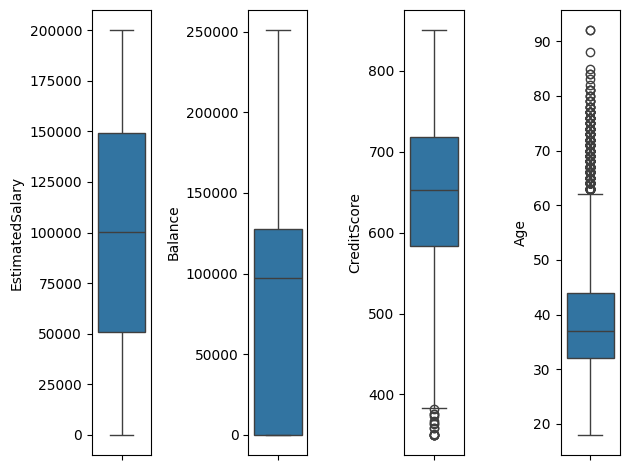

In [181]:
fig, ax = plt.subplots(1,4)

sns.boxplot(y=bc['EstimatedSalary'],ax=ax[0])

sns.boxplot(y=bc['Balance'],ax=ax[1])

sns.boxplot(y=bc['CreditScore'],ax=ax[2])

sns.boxplot(y=bc['Age'],ax=ax[3])

plt.tight_layout()
plt.show()

### CROSS-FIELD INCONSISTENCY
* Validated the relationship between Age and Tenure. While some customers joined the bank prior to age 18 (Age - Tenure < 18), these records were retained as they likely represent student or minor accounts that transitioned into adult accounts. No "impossible" joiner ages were detected.

In [182]:
under_age_joiners = bc[(bc['Age']-bc['Tenure'])<18]
uaj = pd.DataFrame(under_age_joiners)
uaj['UnderAgeJoiners'] = uaj['Age']-uaj['Tenure']
uaj

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,UnderAgeJoiners
17,15788218,Henderson,549,Spain,Female,24.0,9,14406.41,0.00,2,Yes,Yes,0,15.0
68,15755648,Pisano,675,France,Female,21.0,8,18203.00,98373.26,1,No,No,0,13.0
97,15604348,Allard,710,Spain,Male,22.0,8,99645.04,0.00,2,No,No,0,14.0
127,15591607,Fernie,770,France,Male,24.0,9,167256.35,101827.07,1,No,No,0,15.0
143,15800703,Madukwe,485,Spain,Female,21.0,5,54141.50,113157.22,1,Yes,Yes,0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9821,15658980,Matthews,711,Germany,Male,26.0,9,19262.05,128793.63,1,No,No,0,17.0
9884,15646310,Mao,684,Spain,Male,24.0,8,22527.27,143582.89,1,Yes,Yes,0,16.0
9885,15697606,Sturdee,637,France,Female,21.0,10,175072.47,125712.20,1,No,No,0,11.0
9929,15813451,Fleetwood-Smith,677,Spain,Male,18.0,8,114858.90,134796.87,2,Yes,Yes,0,10.0


In [183]:
uaj['UnderAgeJoiners'].min()

np.float64(8.0)

### REPLACING VALUES
* In 'Exited' column 1 means Yes and 0 means No.
* Though this project is not for machine learning purpose I am changing the 1 and 0 to Yes and No for the easiness of understanding.

In [184]:
bc['Exited'] = bc['Exited'].replace({1:'Yes',0:'No'})

## **EXPLORATORY DATA ANALYSIS**

### **UNIVARIATE ANALYSIS**

### Summary statistics
* To find mean, median (50%), standard deviation, IQR (75%-25%) of all numerical columns.

In [185]:
bc.describe()

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts
count,9.997000e+03,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000
mean,1.569094e+07,650.545364,38.922077,5.013204,100092.222656,76482.679807,1.530359
std,7.193443e+04,96.657932,10.489072,2.892364,57518.775702,62397.174721,0.581669
min,1.556570e+07,350.000000,18.000000,0.000000,11.580000,0.000000,1.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,50974.570000,0.000000,1.000000
50%,1.569073e+07,652.000000,37.000000,5.000000,100236.020000,97188.620000,1.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,149399.700000,127642.440000,2.000000
max,1.581569e+07,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000


* To find number of unique values and most frequent values in categorical column.

In [186]:
bc.select_dtypes('string').describe()

,Surname,Geography,Gender,HasCrCard,IsActiveMember
count,9997,9997,9997,9997,9997
unique,2932,3,2,2,2
top,Smith,France,Male,Yes,Yes
freq,32,5013,5456,5149,5149


### Outliers
* Checking statistical outliers to understand data.

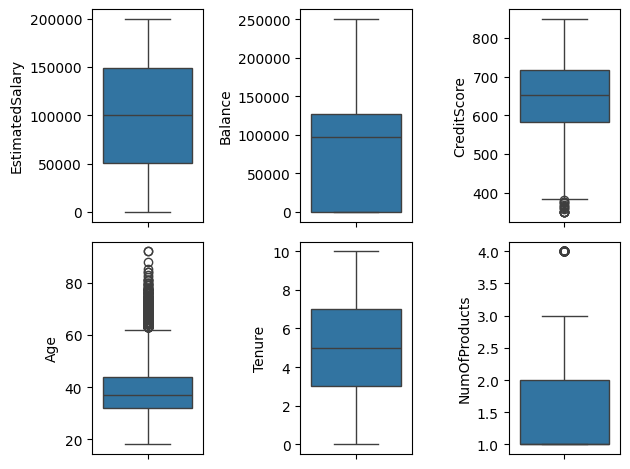

In [187]:
fig, ax = plt.subplots(2,3)
sns.boxplot(y=bc['EstimatedSalary'],ax=ax[0,0])
sns.boxplot(y=bc['Balance'],ax=ax[0,1])
sns.boxplot(y=bc['CreditScore'],ax=ax[0,2])
sns.boxplot(y=bc['Age'],ax=ax[1,0])
sns.boxplot(y=bc['Tenure'],ax=ax[1,1])
sns.boxplot(y=bc['NumOfProducts'],ax=ax[1,2])
plt.tight_layout()
plt.show()

### Credit score
* Credit Score (Range: 500 points): Scores span from 350 to 850. This wide gap suggests there are customers with very poor credit and those with perfect credit.
* The alignment of Mean and Median around 650 indicates a normal distribution of credit scores.
* A noticeable spike at 850 indicates a significant segment of customers with maximum credit scores.
* The standard deviation is 96.65 points. While the full range is wide (350–850), following the empirical rule, approximately 68% of customers have a credit score within one std of the mean (roughly between 550 and 750).

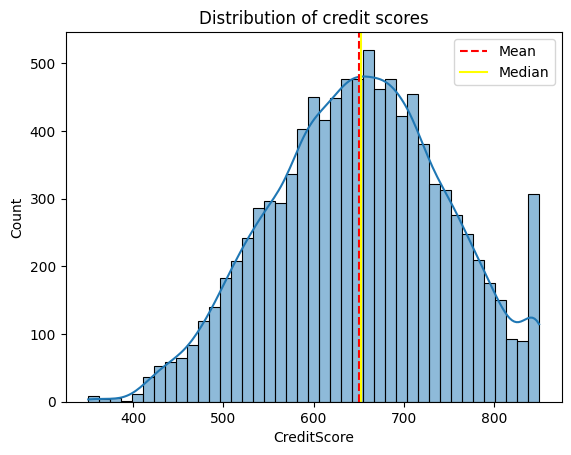

In [188]:
sns.histplot(x='CreditScore', data=bc, kde=True)
plt.title('Distribution of credit scores')
plt.axvline(bc['CreditScore'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(bc['CreditScore'].median(), color='yellow', linestyle='-', label='Median')
plt.legend()
plt.show()

### Tenure
* The data shows a Uniform Distribution between years 1 and 9, indicating consistent customer acquisition over the last decade.
* The lower counts at Tenure 0 and 10 represent the natural entry and exit points of the customer lifecycle.
* The Mean and Median are both exactly 5 years, with an Interquartile Range (IQR) spanning from 3 to 7 years.

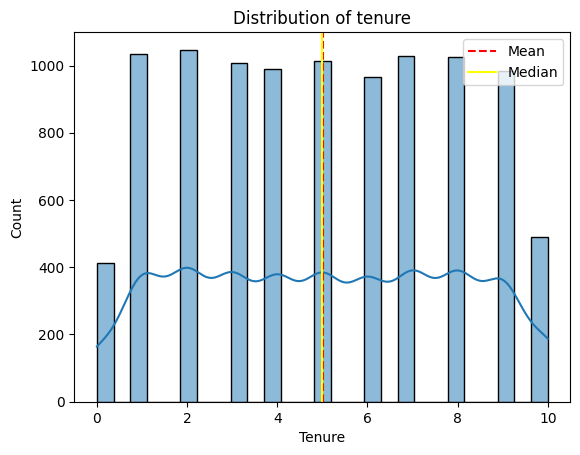

In [189]:
sns.histplot(x='Tenure',data=bc,kde=True)
plt.title('Distribution of tenure')
plt.axvline(bc['Tenure'].mean(),color='red',linestyle='--',label='Mean')
plt.axvline(bc['Tenure'].median(),color='yellow',label='Median')
plt.legend()
plt.show()

### Estimated salary
* Follows a Uniform Distribution, indicating an equal representation of all income brackets within the customer base.
* The Mean and Median are nearly identical at 100,000, confirming a lack of skewness or influential outliers.

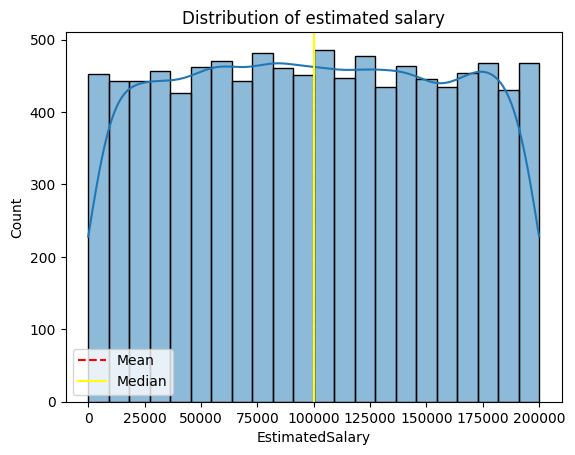

In [190]:
sns.histplot(x=bc['EstimatedSalary'],data=bc,kde=True)
plt.title('Distribution of estimated salary')
plt.axvline(bc['EstimatedSalary'].mean(),color='red',label='Mean',linestyle='--')
plt.axvline(bc['EstimatedSalary'].median(),color='yellow',label='Median')
plt.legend()
plt.show()

### Customers geography
* 50% of the customer base is located in France. France has a high frequency of 5,013 customers, which is double the count for Germany (2,508) or Spain (2,476).
* This proves the bank is primarily French-based, meaning the overall findings will be heavily influenced by the behaviors of this majority.

In [191]:
c =  bc.value_counts('Geography')
p = bc.value_counts('Geography',normalize=True)*100
pd.DataFrame({'count':c,'percentage':p}).reset_index()

,Geography,count,percentage
0,France,5013,50.145044
1,Germany,2508,25.087526
2,Spain,2476,24.767430


### Customers gender
* 54.57% of customers are male and 45.4% are female.

In [192]:
c =  bc.value_counts('Gender')
p = bc.value_counts('Gender',normalize=True)*100
pd.DataFrame({'count':c,'percentage':p}).reset_index()

,Gender,count,percentage
0,Male,5456,54.576373
1,Female,4541,45.423627


### Number of products used by each customer
* The distribution of NumOfProducts is heavily concentrated at 1 (5081 customers) and 2 (4590) units, accounting for 96.7% of the total customer base.
* The Median of 1.0 indicates that the majority of the bank's clients uses only a single product.
* The sharp "cliff" after 2 products suggests that 3 or 4 products are statistical anomalies for this bank's current model. Should prioritize investigating these segments.

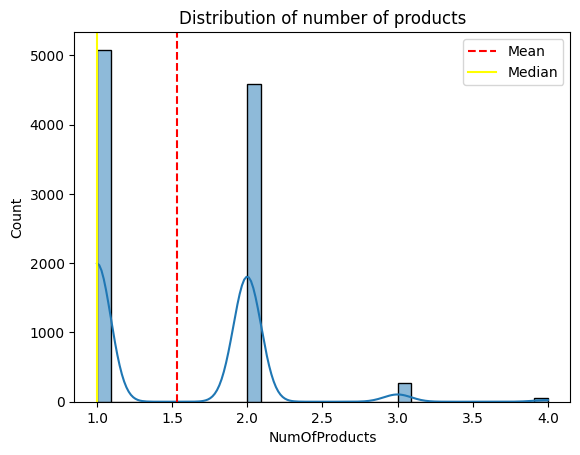

In [193]:
sns.histplot(x=bc['NumOfProducts'],data=bc,kde=True)
plt.title('Distribution of number of products')
plt.axvline(bc['NumOfProducts'].mean(),color='red',label='Mean',linestyle='--')
plt.axvline(bc['NumOfProducts'].median(),color='yellow',label='Median')
plt.legend()
plt.show()

In [194]:
c =  bc.value_counts('NumOfProducts')
p = bc.value_counts('NumOfProducts',normalize=True)*100
pd.DataFrame({'count':c,'percentage':p}).reset_index()

,NumOfProducts,count,percentage
0,1,5081,50.825248
1,2,4590,45.913774
2,3,266,2.660798
3,4,60,0.600180


### Customers having and not having credit cards
* 51.5% of customers have credit card and 48.5% have no credit card.

In [195]:
c =  bc.value_counts('HasCrCard')
p = bc.value_counts('HasCrCard',normalize=True)*100
pd.DataFrame({'count':c,'percentage':p}).reset_index()

,HasCrCard,count,percentage
0,Yes,5149,51.505452
1,No,4848,48.494548


### Active and inactive customers
* 48.5% (4,848 customers) of customers are classified as inactive, representing a significant segment at risk for churn.

In [196]:
c =  bc.value_counts('IsActiveMember')
p = bc.value_counts('IsActiveMember',normalize=True)*100
pd.DataFrame({'count':c,'percentage':p}).reset_index()

,IsActiveMember,count,percentage
0,Yes,5149,51.505452
1,No,4848,48.494548


### Churned customers
* 20.37% of total customers have churned.

In [197]:
c =  bc.value_counts('Exited')
p = bc.value_counts('Exited',normalize=True)*100
pd.DataFrame({'count':c,'percentage':p}).reset_index()

,Exited,count,percentage
0,No,7960,79.623887
1,Yes,2037,20.376113


### Age
* Age (Range: 74 years): With a minimum of 18 and a maximum of 92, bank serves everyone from young students to retirees.
* The customer base is right-Skewed, with a median age of 37 and a mean of 38.9.
* A significant "long tail" exists for customers aged 60+. That requires specialized churn analysis.
* Most customers (50%) are concentrated in a 12-year window. The gap between 25% (32 years) and 75% (44 years) is small compared to the full range of 18–92.

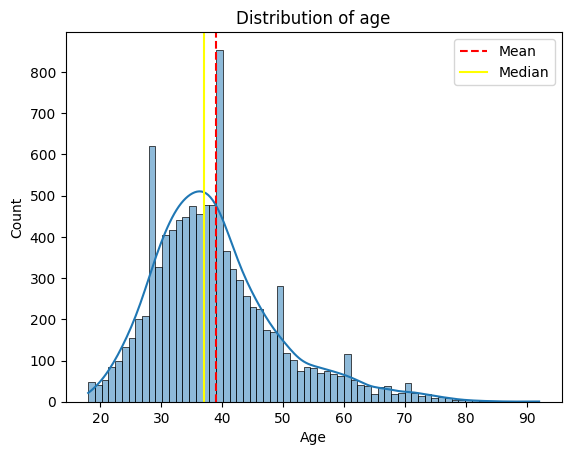

In [198]:
sns.histplot(x='Age',data=bc,kde=True)
plt.title('Distribution of age')
plt.axvline(bc['Age'].mean(),color='red',label='Mean',linestyle='--')
plt.axvline(bc['Age'].median(),color='yellow',label='Median')
plt.legend()
plt.show()

### Account balance
* Balance (Range: 250,898): Range starts at 0 and goes up to over 250k.
* The data shows a Bimodal Distribution with a significant spike at 0, indicating a large segment of non-funded or dormant accounts.
* 36.17% of total customer accounts have 0 balance.
* Excluding the zero-balance peak, the remaining data follows a Normal Distribution centered around 120,000.
* The Median (97,188) is a more robust measure of central tendency here than the Mean (76,482), which is heavily skewed by the high volume of zero-balance entries.

In [199]:
c =  bc.value_counts('Balance')
p = bc.value_counts('Balance',normalize=True)*100
pd.DataFrame({'count':c,'percentage':p}).reset_index().head()

,Balance,count,percentage
0,0.00,3616,36.170851
1,130170.82,2,0.020006
2,105473.74,2,0.020006
3,83807.86,1,0.010003
4,159660.80,1,0.010003


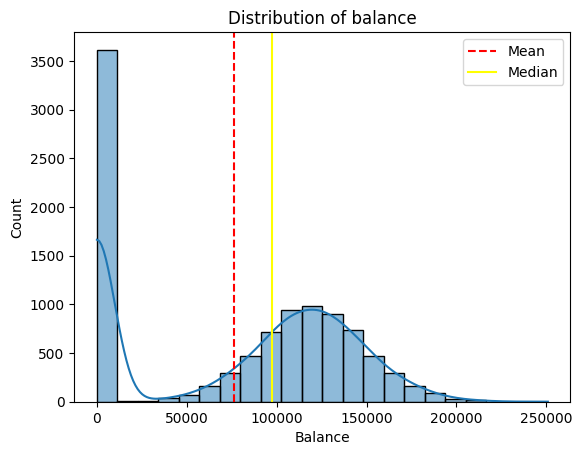

In [200]:
sns.histplot(x=bc['Balance'],data=bc,kde=True)
plt.title('Distribution of balance')
plt.axvline(bc['Balance'].mean(),color='red',label='Mean',linestyle='--')
plt.axvline(bc['Balance'].median(),color='yellow',label='Median')
plt.legend()
plt.show()

### **BIVARIATE AND MULTIVARIATE ANALYSIS**

#### **WHAT ATTRIBUTES ARE MORE COMMON AMONG CHURNERS THAN NON-CHURNERS?**
*20.37% is the churn rate among the total customer base.*

Churners are disproportionately associated with:

* **Demographics & Geography**
    * Customers from Germany (32.45% churn vs ~16% in others)
    * Older customers, especially 40+, with peak churn in 50–60 age group (56.2%)

* **Behaviour & Engagement**
    * Inactive members (26.85% churn vs 14.27% active)
    * Customers with only 1 product (27.7% churn)
    * Customers with 3 or more products (extremely high churn, 82–100%)

* **Financial Profile**
* Low balance customers (33.66% churn)
* Higher balance customers also show elevated churn (25.22%)

* **Gender**
    * Female customers (25% churn vs 16.45% males)
    * Particularly:
        * Low-balance females (46.5% churn)
        * High-balance females (30.4% churn)

* **Early Tenure**
    * Customers with 0–1 year tenure show slightly higher churn (~22–23%)

#### **CAN CHURN BE PREDICTED USING THE VARIABLES IN THE DATA?**
* Yes, churn can be predicted using these variables:
  * Age
  * Geography
  * Activity status
  * Number of products
  * Balance
  * Gender

These variables show strong separation between churners and non-churners

#### Geography
* At a 32.45% churn rate, a German customer is twice as likely to leave as a French or Spanish one.

In [201]:
bc.value_counts('Geography')


Geography
France     5013
Germany    2508
Spain      2476
Name: count, dtype: int64

In [202]:
pd.crosstab(bc['Geography'], bc['Exited'], normalize='index') * 100

Exited,No,Yes
Geography,,
France,83.842011,16.157989
Germany,67.543860,32.456140
Spain,83.319871,16.680129


#### Credit Score
* Poor credit score category has 22.16% churn rate. Which is a little higher than total customer churn rate of 20.37%.

In [203]:
bc.groupby('Exited')['CreditScore'].agg(['mean','median'])

,mean,median
Exited,,
No,651.874497,653.0
Yes,645.351497,646.0


In [204]:
bc['CreditScoreStatus'] = pd.cut(bc['CreditScore'],
                                 bins=[350, 580, 670, 740, 800, 850],
                                 labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'],
                                 include_lowest=True)

In [205]:
bc['CreditScoreStatus'].value_counts()

CreditScoreStatus
Fair         3350
Good         2396
Poor         2391
Very Good    1215
Excellent     645
Name: count, dtype: int64

In [206]:
pd.crosstab(bc['CreditScoreStatus'], bc['Exited'], normalize='index') * 100

Exited,No,Yes
CreditScoreStatus,,
Poor,77.833542,22.166458
Fair,79.611940,20.388060
Good,81.176962,18.823038
Very Good,79.753086,20.246914
Excellent,80.310078,19.689922


#### Gender
* Females are significantly more likely to churn (25%) than males (16.45%).

In [207]:
pd.crosstab(bc['Gender'], bc['Exited'], normalize='index') * 100

Exited,No,Yes
Gender,,
Female,74.917419,25.082581
Male,83.541056,16.458944


#### Age
* Among 40-50 age group churn rate is 33.9% and among 50-60 it's 56.2% (Over half left). And among 60+ is 24.78%. Older customers tend to churn more.
* Churn rate is just 7.45% among customers who joined as minors. Their retention rate is 92.5%.

In [208]:
bc.groupby('Exited')['Age'].agg(['mean','median'])

,mean,median
Exited,,
No,37.408166,36.0
Yes,44.837997,45.0


In [209]:
bc['AgeGroup'] = pd.cut(bc['Age'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18-30', '30-40', '40-50', '50-60', '60+'],
                       include_lowest=True)

In [210]:
pd.crosstab(bc['AgeGroup'], bc['Exited'], normalize='index') * 100

Exited,No,Yes
AgeGroup,,
18-30,92.479675,7.520325
30-40,87.907395,12.092605
40-50,66.019836,33.980164
50-60,43.789210,56.210790
60+,75.215517,24.784483


In [211]:
# Minor joiners
uaj['Exited'] = uaj['Exited'].replace({0:'No',1:'Yes'})
uaj['Exited'].value_counts(normalize=True) * 100

Exited
No     92.546584
Yes     7.453416
Name: proportion, dtype: float64

#### Tenure
* Churn rate is 23% among customers have 0 year tenure. 22.4% for 1 year. 21.6% for 9 year. Churn rate seems a little high in new customers.

In [212]:
(pd.crosstab(bc['Tenure'], bc['Exited'], normalize='index') * 100).sort_values(by='Yes',ascending=False)

Exited,No,Yes
Tenure,,
0,76.997579,23.002421
1,77.584541,22.415459
9,78.353659,21.646341
3,78.869048,21.130952
5,79.347826,20.652174
10,79.387755,20.612245
4,79.474216,20.525784
6,79.710145,20.289855
8,80.780488,19.219512


#### Estimated Salary
* 21.56% churn rate among very high salary category. Others are 20 or below. Very High Salary group shows a slight uptick in churn.

In [213]:
bc.groupby('Exited')['EstimatedSalary'].agg(['mean','median'])

,mean,median
Exited,,
No,99740.749342,99620.355
Yes,101465.677531,102460.840


In [214]:
bc['SalaryStatus'] = pd.qcut(bc['EstimatedSalary'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

In [215]:
pd.crosstab(bc['SalaryStatus'], bc['Exited'], normalize='index') * 100

Exited,No,Yes
SalaryStatus,,
Low,80.000000,20.000000
Medium,80.152061,19.847939
High,79.911965,20.088035
Very High,78.431373,21.568627


#### Balance
* The difference between median salary of churned (109349.29) and retained (92063) customers shows that the bank is losing its high value customers.
* Zero balance accounts have 13.8% of churn. Low balance accounts have 33.66 churn. Medium have 19.88 and high balance have 25.22% of churn.

In [216]:
bc.groupby('Exited')['Balance'].agg(['mean','median'])

,mean,median
Exited,,
No,72739.856206,92063.06
Yes,91108.539337,109349.29


In [217]:
bc['BalanceStatus'] = pd.cut(bc['Balance'], bins=[-1, 0, 50000, 100000, 250898], labels=['Zero', 'Low', 'Medium', 'High'])

In [218]:
pd.crosstab(bc['BalanceStatus'], bc['Exited'], normalize='index') * 100

Exited,No,Yes
BalanceStatus,,
Zero,86.172566,13.827434
Low,65.333333,34.666667
Medium,80.119284,19.880716
High,74.770642,25.229358


#### Number Of Products
* 50% (5081) of customers use only 1 product. 45.9% (4590) of customers use 2 products. 2.66% (266) use 3 products. 0.6% (60) use 4 products.
* All customers who used to use 4 products were churned (100%). 82.7% of customers who used to use 3 products were churned. Churn is 7.58% in 2 product users. 27.7% is churn rate of 1 product users.

In [219]:
pd.crosstab(bc['NumOfProducts'], bc['Exited'], normalize='index') * 100

Exited,No,Yes
NumOfProducts,,
1,72.269238,27.730762
2,92.418301,7.581699
3,17.293233,82.706767
4,0.000000,100.000000


#### Has Credit Card
* 26.85% of no credit card users churned. 14.27% of credit card users churned.

In [220]:
pd.crosstab(bc['HasCrCard'], bc['Exited'], normalize='index') * 100

Exited,No,Yes
HasCrCard,,
No,73.143564,26.856436
Yes,85.725384,14.274616


#### Is Active Member
* 26.85% of inactive members churned. 14.27% of active members churned. Being an active member nearly cuts churn in half (14.27% vs 26.85%).
* And another interesting fact here is all credit card holders are active members and all non credit card holders are inactive members.

In [221]:
pd.crosstab(bc['IsActiveMember'], bc['Exited'], normalize='index') * 100

Exited,No,Yes
IsActiveMember,,
No,73.143564,26.856436
Yes,85.725384,14.274616


In [222]:
# are credit card holders and active customers same?
ccac = bc['HasCrCard'] == bc['IsActiveMember']
tf = pd.DataFrame({'T/F':ccac})
tf[tf['T/F']==False]

,T/F


In [223]:
pd.crosstab(bc['HasCrCard'], bc['IsActiveMember'])

IsActiveMember,No,Yes
HasCrCard,,
No,4848,0
Yes,0,5149


* **GEOGRAPHY + AGE + CHURN**

**Why:** Found that Germany has a 32.45% churn rate and the 50–60 age group has a 56.2% churn rate.
* While the global churn rate is 20.37% and overall churn rate among 50-60 age group is 56.2%, German customers in this age bracket exhibit a 69.5% churn rate.

In [224]:
age = bc[bc['AgeGroup']=='50-60']
age.groupby('Geography') ['Exited'].value_counts(normalize=True) * 100

Geography  Exited
France     Yes       52.588556
           No        47.411444
Germany    Yes       69.547325
           No        30.452675
Spain      No        54.010695
           Yes       45.989305
Name: proportion, dtype: float64

**ACTIVITY + NUMBER OF PRODUCTS USING + CHURN**

**Why:** Found that 3-product users churn at 82% and Inactive members churn at 26%.
* Activity significantly boosts retention for 1 and 2-product holders, but its effectiveness evaporates as product counts increase. Customers with 4 products exhibit a 100% churn rate regardless of their activity status.

In [225]:
bc.groupby(['NumOfProducts','IsActiveMember']) ['Exited'].value_counts(normalize=True) * 100

NumOfProducts  IsActiveMember  Exited
1              No              No         63.333333
                               Yes        36.666667
               Yes             No         81.062085
                               Yes        18.937915
2              No              No         90.111940
                               Yes         9.888060
               Yes             No         94.439902
                               Yes         5.560098
3              No              Yes        88.235294
                               No         11.764706
               Yes             Yes        75.221239
                               No         24.778761
4              No              Yes       100.000000
               Yes             Yes       100.000000
Name: proportion, dtype: float64

**GENDER + BALANCE + CHURN**

**Why:** Found females and high-balance customers churn more (~25%).
* High-Balance Females churn at a 30.4% rate, nearly 10 percentage higher than males in the same wealth bracket.
* The bank is facing a 46.5% churn rate among Low-Balance Females.

In [226]:
bc.groupby(['BalanceStatus','Gender']) ['Exited'].value_counts(normalize=True) * 100

BalanceStatus  Gender  Exited
Zero           Female  No        82.456140
                       Yes       17.543860
               Male    No        89.302089
                       Yes       10.697911
Low            Female  No        53.488372
                       Yes       46.511628
               Male    No        81.250000
                       Yes       18.750000
Medium         Female  No        74.785100
                       Yes       25.214900
               Male    No        84.710234
                       Yes       15.289766
High           Female  No        69.585468
                       Yes       30.414532
               Male    No        78.973197
                       Yes       21.026803
Name: proportion, dtype: float64

**BALANCE + ACTIVITY + CHURN**

**Why:** Found that Zero-Balance accounts have very low churn (13.8%).
* 51.76% of zero balance accounts are active.
* Churn is very less (9.6%) among active zero balance accounts.

In [227]:
bc.groupby('BalanceStatus') ['IsActiveMember'].value_counts(normalize=True) * 100

BalanceStatus  IsActiveMember
Zero           Yes               51.769912
               No                48.230088
Low            Yes               53.333333
               No                46.666667
Medium         Yes               52.683897
               No                47.316103
High           Yes               50.896580
               No                49.103420
Name: proportion, dtype: float64

In [228]:
bc.groupby(['BalanceStatus','IsActiveMember']) ['Exited'].value_counts(normalize=True) * 100

BalanceStatus  IsActiveMember  Exited
Zero           No              No        81.651376
                               Yes       18.348624
               Yes             No        90.384615
                               Yes        9.615385
Low            No              Yes       51.428571
                               No        48.571429
               Yes             No        80.000000
                               Yes       20.000000
Medium         No              No        73.109244
                               Yes       26.890756
               Yes             No        86.415094
                               Yes       13.584906
High           No              No        67.218684
                               Yes       32.781316
               Yes             No        82.056534
                               Yes       17.943466
Name: proportion, dtype: float64

**AGE + ACTIVITY + CHURN**

**Why:** Found that older age groups and inactive customers have high churn.
* Among inactive accounts of 60+, 82% churned. In 50-60 it's 85.7% and in 40-50 it's 41.6%.
* It is clear that inactive accounts of older age group churns extremely high.

In [229]:
bc.groupby(['AgeGroup','IsActiveMember']) ['Exited'].value_counts(normalize=True) * 100

AgeGroup  IsActiveMember  Exited
18-30     No              No        89.916840
                          Yes       10.083160
          Yes             No        94.930417
                          Yes        5.069583
30-40     No              No        85.055928
                          Yes       14.944072
          Yes             No        90.785908
                          Yes        9.214092
40-50     No              No        58.401305
                          Yes       41.598695
          Yes             No        74.565416
                          Yes       25.434584
50-60     No              Yes       85.714286
                          No        14.285714
          Yes             No        65.292842
                          Yes       34.707158
60+       No              Yes       82.022472
                          No        17.977528
          Yes             No        88.800000
                          Yes       11.200000
Name: proportion, dtype: float64

#### **WHAT DO THE OVERALL DEMOGRAPHICS OF THE BANK'S CUSTOMERS LOOK LIKE?**
* **Age**
    * The customer base is tightly concentrated in the working-age bracket. About 50% fall between 32 and 44 years, with a median age of 37. That tells that “typical” customer is mid-career, not young entrants or retirees.
    * The distribution is right-skewed, meaning there are fewer older customers stretching the tail up to 92. So it’s not youth-heavy, it’s slightly tilted towards older ages, but the core mass is still mid-aged.
* **Gender**
   * 54.57% of customers are male and 45.4% are female. This is a mild imbalance, not extreme, but still noticeable.
* **Geography**
    * France: 50%, Germany: 25%, Spain: 25%
    * France clearly dominates the customer base with 50%. So the business is heavily dependent on one region.
* **Financial status**
    * Most customers fall in the fair credit score category (581–670). That’s below “good”, means the bank is not dealing with a high-credit-quality base. Higher default risk compared to a “good” or “excellent” base.
    * Salary is uniformly distributed. That means all income levels are equally represented.
    * 36.17% of customers have zero balance. This is a big red flag.
    * The rest follow a roughly normal distribution.

#### **IS THERE A DIFFERENCE BETWEEN GERMAN, FRENCH, AND SPANISH CUSTOMERS IN TERMS OF ACCOUNT BEHAVIOR?**
* **Balance comparison**
  * Germans hold more money in their accounts. Their mean balance is 119721 and median is 119699.
  * 66.84% of total zero balance accounts are from France and 33.15% are from Spain. Germans don't hold any zero balance accounts.
* **Product usage**
  * France and Spain show a very similar distribution, with customers almost evenly split between 1 and 2 products.
  * Germany has a higher concentration of single-product customers, indicating lower product adoption.
  * Although Spain’s median is 2, the distribution shows that customers are still nearly evenly divided between 1 and 2 products. This means the median slightly overstates the difference. Spain is only marginally different from France
* **Activity level**
  * Spain have the highest 52.98% active members and  Germany have the least with 49.7%.
* **Credit card ownership**
  * Spain have the highest 52.98% credit card holders and  Germany have the least with 49.7%.
* **Tenure**
  * Average tenure of customers from all countries seems 5.

In [230]:
bc.groupby('Geography').agg({'Balance': ['mean','median'],'NumOfProducts': ['mean','median'],'Tenure': ['mean','median']})

Balance             NumOfProducts           Tenure       
                    mean      median          mean median      mean median
Geography                                                                 
France      62105.022839   62212.290      1.531019    1.0  5.005187    5.0
Germany    119721.495993  119699.425      1.519936    1.0  5.010766    5.0
Spain       61794.571321   61700.945      1.539580    2.0  5.031906    5.0

In [231]:
pd.crosstab(bc['Geography'], bc['NumOfProducts'], normalize='index') * 100

NumOfProducts,1,2,3,4
Geography,,,,
France,50.129663,47.217235,2.074606,0.578496
Germany,53.748006,41.467305,3.827751,0.956938
Spain,49.273021,47.778675,2.665590,0.282714


In [232]:
bc[bc['Balance']==0].value_counts('Geography',normalize=True) * 100

Geography
France    66.841814
Spain     33.158186
Name: proportion, dtype: float64

In [233]:
pd.crosstab(bc['Geography'], bc['IsActiveMember'], normalize='index') * 100

IsActiveMember,No,Yes
Geography,,
France,48.334331,51.665669
Germany,50.279107,49.720893
Spain,47.011309,52.988691


In [234]:
pd.crosstab(bc['Geography'], bc['HasCrCard'], normalize='index') * 100

HasCrCard,No,Yes
Geography,,
France,48.334331,51.665669
Germany,50.279107,49.720893
Spain,47.011309,52.988691


#### **WHAT TYPE OF SEGMENTS EXISTS WITHIN THE BANK'S CUSTOMERS?**

* **Stable Core Customers**
    * France
    * Active members
    * 2 products
    * Medium or above balance (>50000)
    * Males
    * Age 18-40

Their churn rate is very low (4.9%).

They are the most stable and core customers of the bank.

But they are just 1.22% of the total customers. It's concerning.

In [235]:
seg = bc[(bc['Geography']=='France') &
    (bc['IsActiveMember']=='Yes') &
    (bc['NumOfProducts']==2) &
    (bc['Balance']>50000) &
    (bc['Gender']=='Male') &
    ((bc['Age']>=18) & (bc['Age']<=40))]

(len(seg)/len(bc)) * 100

1.22036610983295

In [236]:
seg.value_counts('Exited',normalize=True) * 100

Exited
No     95.081967
Yes     4.918033
Name: proportion, dtype: float64

* **High-Value but At-Risk Customers**
    * High balance (>100000)
    * Germany
    * Age 50-60 (52% high balance)
    * Inactive

High churn (90%) despite high value

Most critical segment

They are 1.1% of total customers

In [237]:
# bc.groupby('AgeGroup') ['BalanceStatus'].value_counts(normalize=True) * 100

In [238]:
segm = bc[(bc['Geography']=='Germany') &
    (bc['IsActiveMember']=='No') &
    (bc['BalanceStatus']=='High') &
    ((bc['Age']>50) & (bc['Age']<=60))]

(len(segm)/len(bc)) * 100

1.100330099029709

In [239]:
segm.value_counts('Exited',normalize=True) * 100

Exited
Yes    90.0
No     10.0
Name: proportion, dtype: float64

* **Engaged Multi-Product Users**
    * Active
    * 2 products

Their churn rate is just 5.56%.

Strong retention.

They consists of 24.46% of total customers.

In [240]:
segmn = bc[(bc['IsActiveMember']=='Yes') &
          (bc['NumOfProducts']==2)]

(len(segmn)/len(bc)) * 100

24.46734020206062

In [241]:
segmn.value_counts('Exited',normalize=True) * 100

Exited
No     94.439902
Yes     5.560098
Name: proportion, dtype: float64

* **Dormant Customers**
    * Inactive
    * Zero Balance

Weak relationship with bank.

They cosists of 17.44% of total customers.

In [242]:
segme = bc[(bc['IsActiveMember']=='No') &
          (bc['BalanceStatus']=='Zero')]

(len(segme)/len(bc)) * 100

17.44523357007102

In [243]:
segme.value_counts('Exited',normalize=True) * 100

Exited
No     81.651376
Yes    18.348624
Name: proportion, dtype: float64

* **Early-Stage Customers**
  * Low tenure
  * Inactive

Churn rate is 30.15%. Needs monitoring.

They consists of 6.6% of total customers.

In [244]:
segmen = bc[(bc['IsActiveMember']=='No') &
          (bc['Tenure']<=1)]

(len(segmen)/len(bc)) * 100

6.601980594178254

In [245]:
segmen.value_counts('Exited',normalize=True) * 100

Exited
No     69.848485
Yes    30.151515
Name: proportion, dtype: float64

### **VISUALIZATION PREPRATION**

In [246]:
#1. OVERALL CHURN LEVEL
overall_churn = pd.DataFrame(bc['Exited'].value_counts(normalize=True) * 100).reset_index()
overall_churn = overall_churn.rename(columns={'proportion':'Percentage'})

In [247]:
#2. HIGH-RISK CUSTOMER SEGMENT
age = pd.DataFrame(bc.groupby('AgeGroup') ['Exited'].value_counts()).reset_index()
a = age[age['AgeGroup']=='40-50']
b = age[age['AgeGroup']=='50-60']
c = age[age['AgeGroup']=='60+']

agee = pd.DataFrame(bc.groupby(['AgeGroup','IsActiveMember']) ['Exited'].value_counts()).reset_index()
d = agee[(agee['AgeGroup']=='50-60') & (agee['IsActiveMember']=='No')]
d.loc[d['IsActiveMember']=='No','IsActiveMember'] = 'Inactive'
d.loc[d['Exited']=='Yes','Exited'] = 'Churned'
d.loc[d['Exited']=='No','Exited'] = 'Retained'

In [248]:
#3. HIGH-VALUE CUSTOMERS ARE AT RISK
hbs = pd.crosstab(bc['BalanceStatus'], bc['Exited']).reset_index()

In [272]:
#4. ACTIVITY STATUS IS A STRONG CHURN DRIVER
ac = pd.DataFrame(bc.groupby('IsActiveMember')['Exited'].value_counts()).reset_index()
ac = ac.rename(columns={'proportion':'Percentage'})
acn = ac[ac['IsActiveMember']=='No']
acy = ac[ac['IsActiveMember']=='Yes']
acn.loc[acn['Exited']=='No','Exited']='Retained'
acn.loc[acn['Exited']=='Yes','Exited']='Churned'
acy.loc[acy['Exited']=='No','Exited']='Retained'
acy.loc[acy['Exited']=='Yes','Exited']='Churned'

cross_tab = pd.crosstab(bc['HasCrCard'], bc['IsActiveMember'])

In [250]:
#5. PRODUCT USAGE
nopc = bc['NumOfProducts'].value_counts().reset_index()

nop = pd.DataFrame(bc.groupby('NumOfProducts')['Exited'].value_counts(normalize=True) * 100).reset_index()

nop1 = nop[nop['NumOfProducts']==1]
nop2 = nop[nop['NumOfProducts']==2]
nop3 = nop[nop['NumOfProducts']==3]
nop4 = nop[nop['NumOfProducts']==4]

nop1 = nop1.rename(columns={'proportion':'Percentage'})
nop1.loc[nop1['Exited']=='No','Exited']='Retained'
nop1.loc[nop1['Exited']=='Yes','Exited']='Churned'

nop2 = nop2.rename(columns={'proportion':'Percentage'})
nop2.loc[nop2['Exited']=='No','Exited']='Retained'
nop2.loc[nop2['Exited']=='Yes','Exited']='Churned'

nop3 = nop3.rename(columns={'proportion':'Percentage'})
nop3.loc[nop3['Exited']=='No','Exited']='Retained'
nop3.loc[nop3['Exited']=='Yes','Exited']='Churned'

nop4 = nop4.rename(columns={'proportion':'Percentage'})
nop4.loc[nop4['Exited']=='No','Exited']='Retained'
nop4.loc[nop4['Exited']=='Yes','Exited']='Churned'

In [251]:
#6. GENDER-BASED CHURN DIFFERENCE
ge = (bc.groupby('Gender')['Exited'].value_counts(normalize=True) * 100).reset_index()
ge = ge.rename(columns={'proportion':'Percentage'})
gef = ge[ge['Gender']=='Female']
gef.loc[gef['Exited']=='No','Exited']='Retained'
gef.loc[gef['Exited']=='Yes','Exited']='Churned'

In [252]:
#7. HIGH VALUE GERMAN CUSTOMERS
gb = pd.DataFrame(bc.groupby('Geography')['BalanceStatus'].value_counts(normalize=True) * 100).reset_index()
gbc = gb[gb['Geography']=='Germany']
gbc = gbc.rename(columns={'proportion':'Percentage'})

gc = pd.DataFrame(bc.groupby('Geography')['Exited'].value_counts(normalize=True) * 100).reset_index()
gce = gc[gc['Geography']=='Germany']
gce = gce.rename(columns={'proportion':'Percentage'})
gce.loc[gce['Exited']=='No','Exited']='Retained'
gce.loc[gce['Exited']=='Yes','Exited']='Churned'

In [253]:
#8. Early-age onboarding drives strong retention
ua = (uaj['Exited'].value_counts(normalize=True) * 100).reset_index()
ua = ua.rename(columns={'proportion':'Percentage'})
ua.loc[ua['Exited']=='No','Exited']='Retained'
ua.loc[ua['Exited']=='Yes','Exited']='Churned'

### **INSIGHTS, RECOMMENDATION AND VISUALIZATION**

**1. OVERALL CHURN LEVEL**
* Total churn rate is 20.37%, indicating a significant retention problem

***RECOMMENDATION:***
* Focus on targeted retention rather than broad strategies, prioritising high-risk segments

In [254]:
fig = px.pie(overall_churn,names='Exited',values='Percentage',title='CHURN vs RETENTION')
fig.show()

**2. HIGH-RISK CUSTOMER SEGMENT**
* Customers aged 40 and above, especially inactive users, show the highest churn
* Churn peaks at 56.2% in the 50–60 age group and it is 85.7% in inactive 50-60 accounts.

***RECOMMENDATION:***
* Target this segment with retention campaigns, personalised offers, and engagement strategies before churn happens

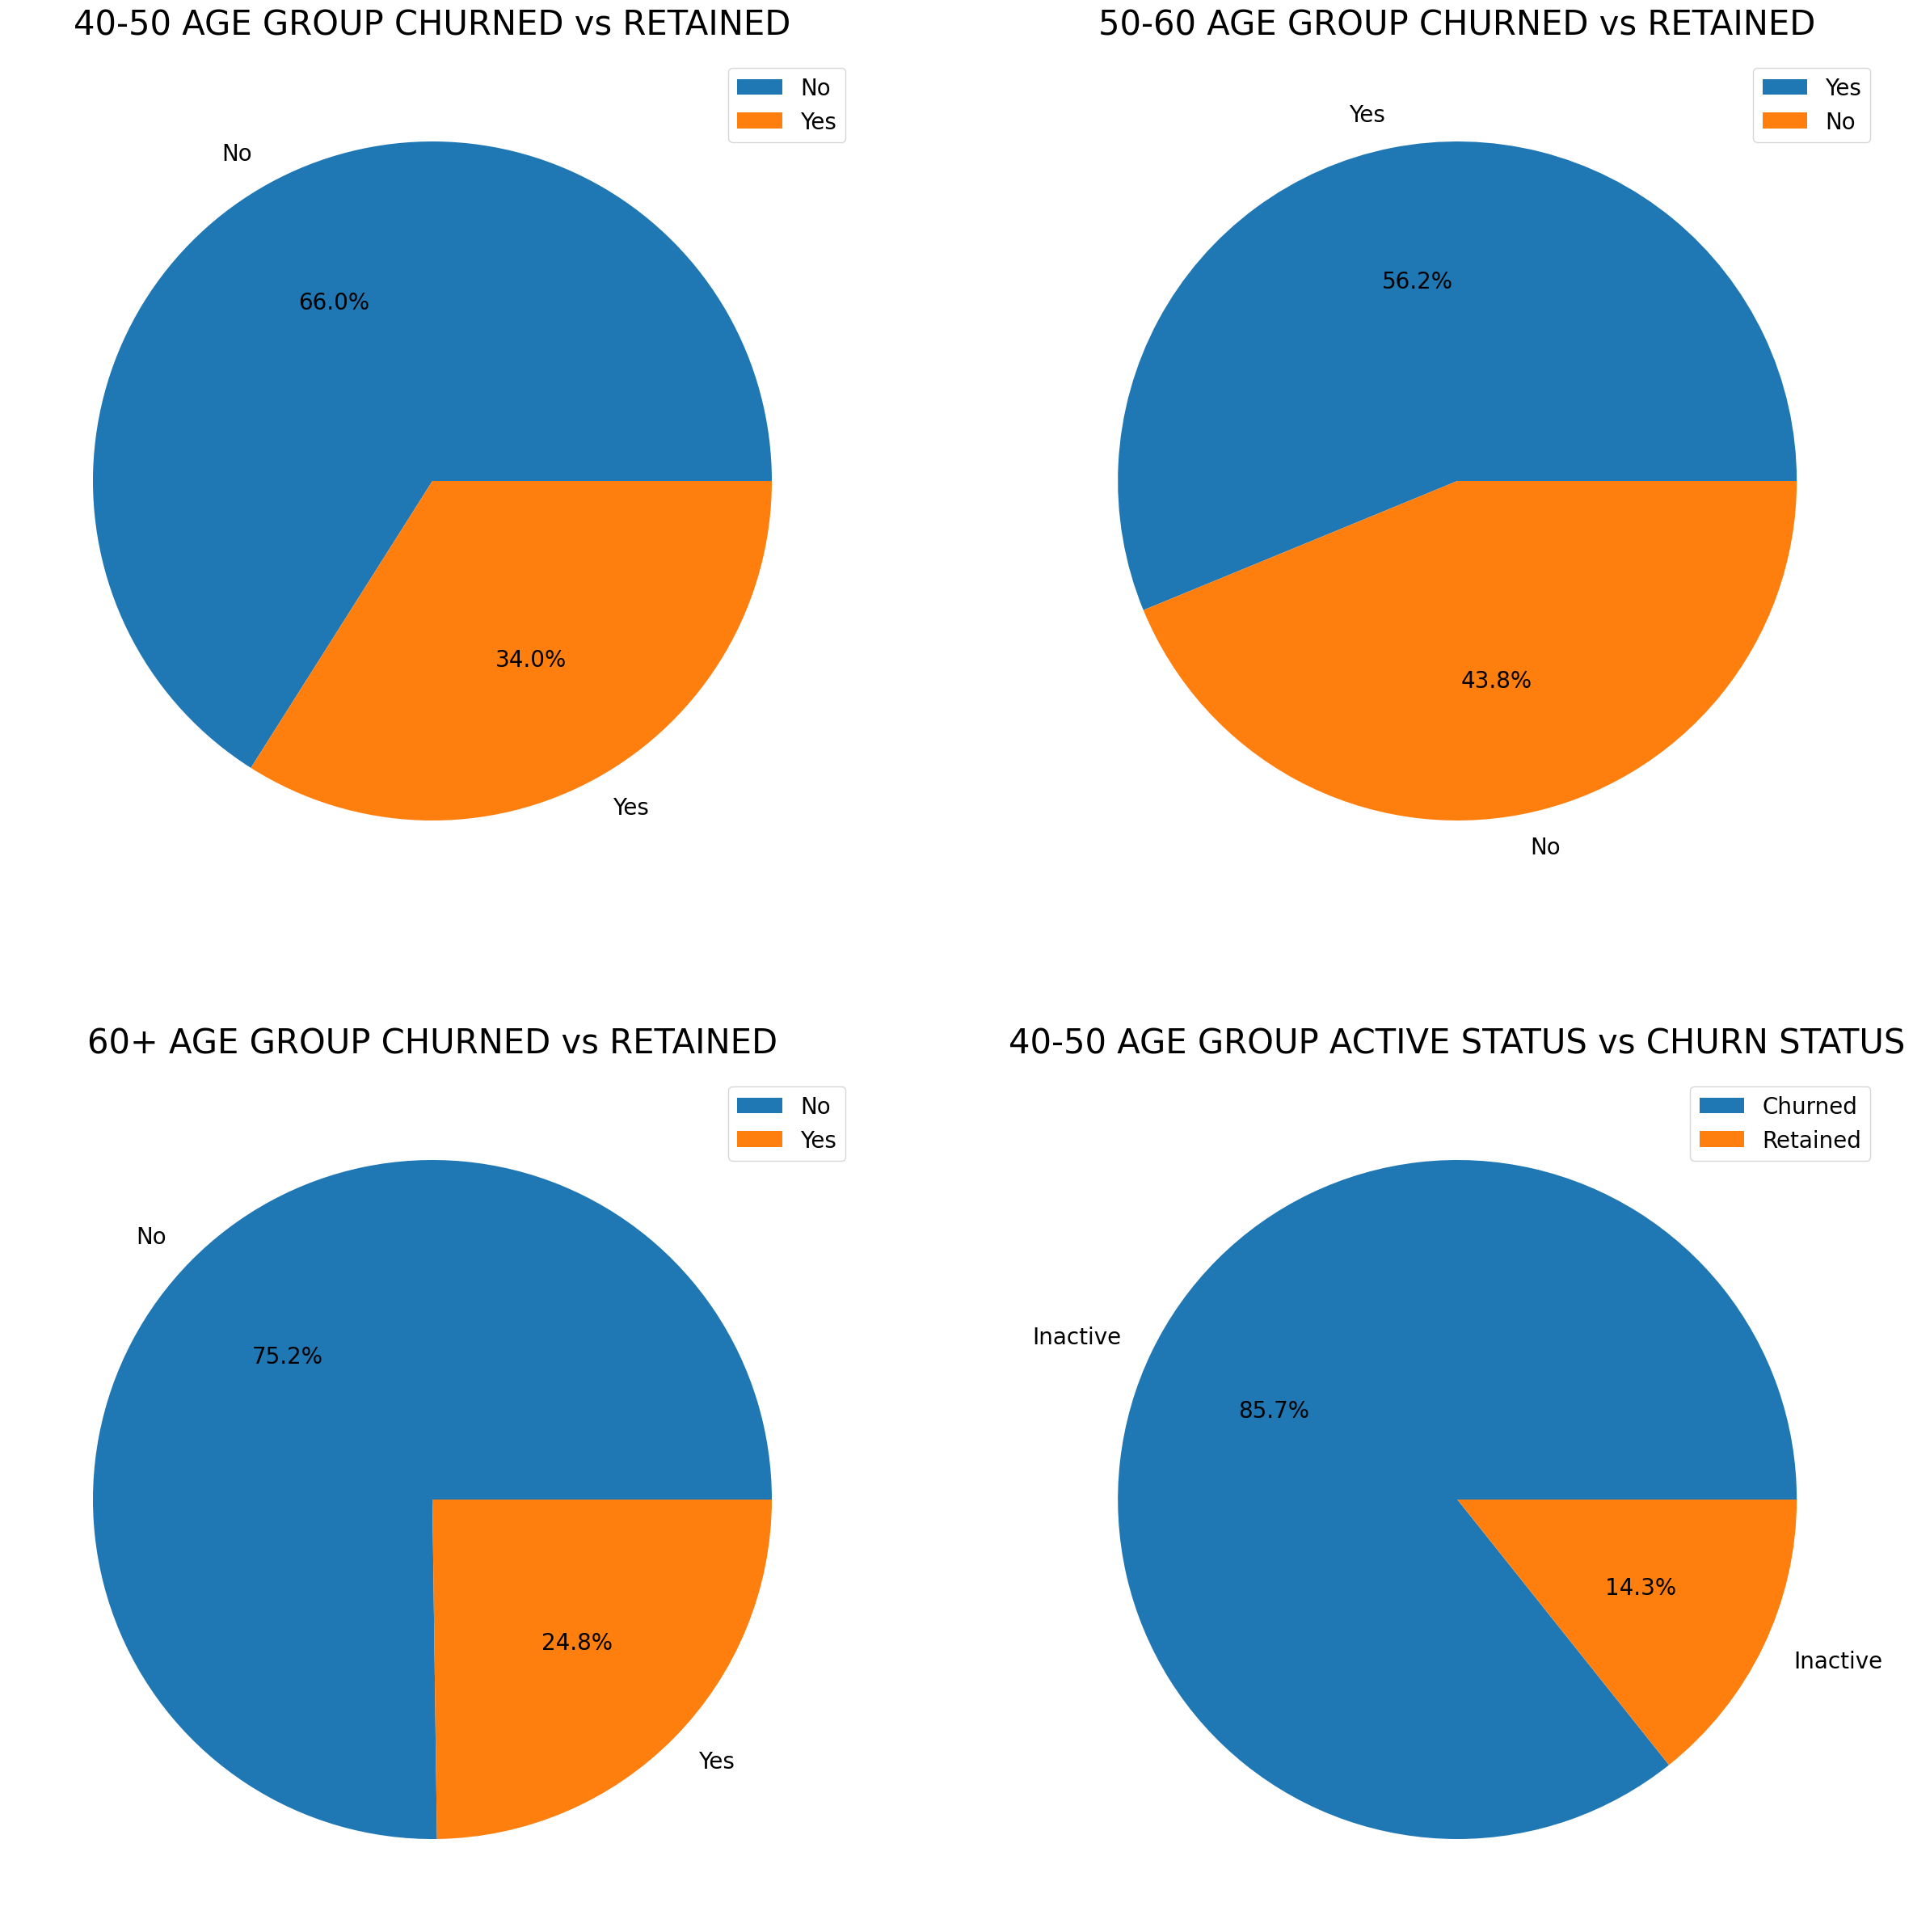

In [255]:
fig, ax = plt.subplots(2,2,figsize=(30,30))

ax[0,0].pie(a['count'],labels=a['Exited'],autopct='%1.1f%%',textprops={'fontsize': 20})
ax[0,0].set_title('40-50 AGE GROUP CHURNED vs RETAINED',fontsize=30, pad=20)
ax[0,0].legend(a['Exited'],prop={'size': 20})

ax[0,1].pie(b['count'],labels=b['Exited'],autopct='%1.1f%%',textprops={'fontsize': 20})
ax[0,1].set_title('50-60 AGE GROUP CHURNED vs RETAINED',fontsize=30, pad=20)
ax[0,1].legend(b['Exited'],prop={'size': 20})

ax[1,0].pie(c['count'],labels=c['Exited'],autopct='%1.1f%%',textprops={'fontsize': 20})
ax[1,0].set_title('60+ AGE GROUP CHURNED vs RETAINED',fontsize=30, pad=20)
ax[1,0].legend(c['Exited'],prop={'size': 20})

ax[1,1].pie(d['count'],labels=d['IsActiveMember'],autopct='%1.1f%%',textprops={'fontsize': 20})
ax[1,1].set_title('40-50 AGE GROUP ACTIVE STATUS vs CHURN STATUS',fontsize=30, pad=20)
ax[1,1].legend(d['Exited'],prop={'size': 20})

plt.show()

**3. HIGH-VALUE CUSTOMERS ARE AT RISK**
* Customers with high account balances contribute the majority of churn volume
* A significant portion (59.4%) of churners come from high-value segments.

***RECOMMENDATION:***
* Prioritise retention of high-balance customers through premium services, relationship management, and loyalty benefits

In [256]:
fig = px.bar(hbs,x='BalanceStatus',y='Yes',title='HIGH BALANCE CHURN COUNT',text_auto='.1f',labels={'Yes': 'Churn Count'})
fig.show()

**4. ACTIVITY STATUS IS A STRONG CHURN DRIVER**
* Inactive customers (48.5% of base) show significantly higher churn (26.85%)
* There is a 100% correlation between Credit card users and active members. The activity is likely defined by credit card usage

***RECOMMENDATION:***
* Improve customer engagement through reminders, offers, and usage incentives to reduce inactivity-driven churn
* Offer a low-barrier or entry level Credit Card specifically to the Inactive segment

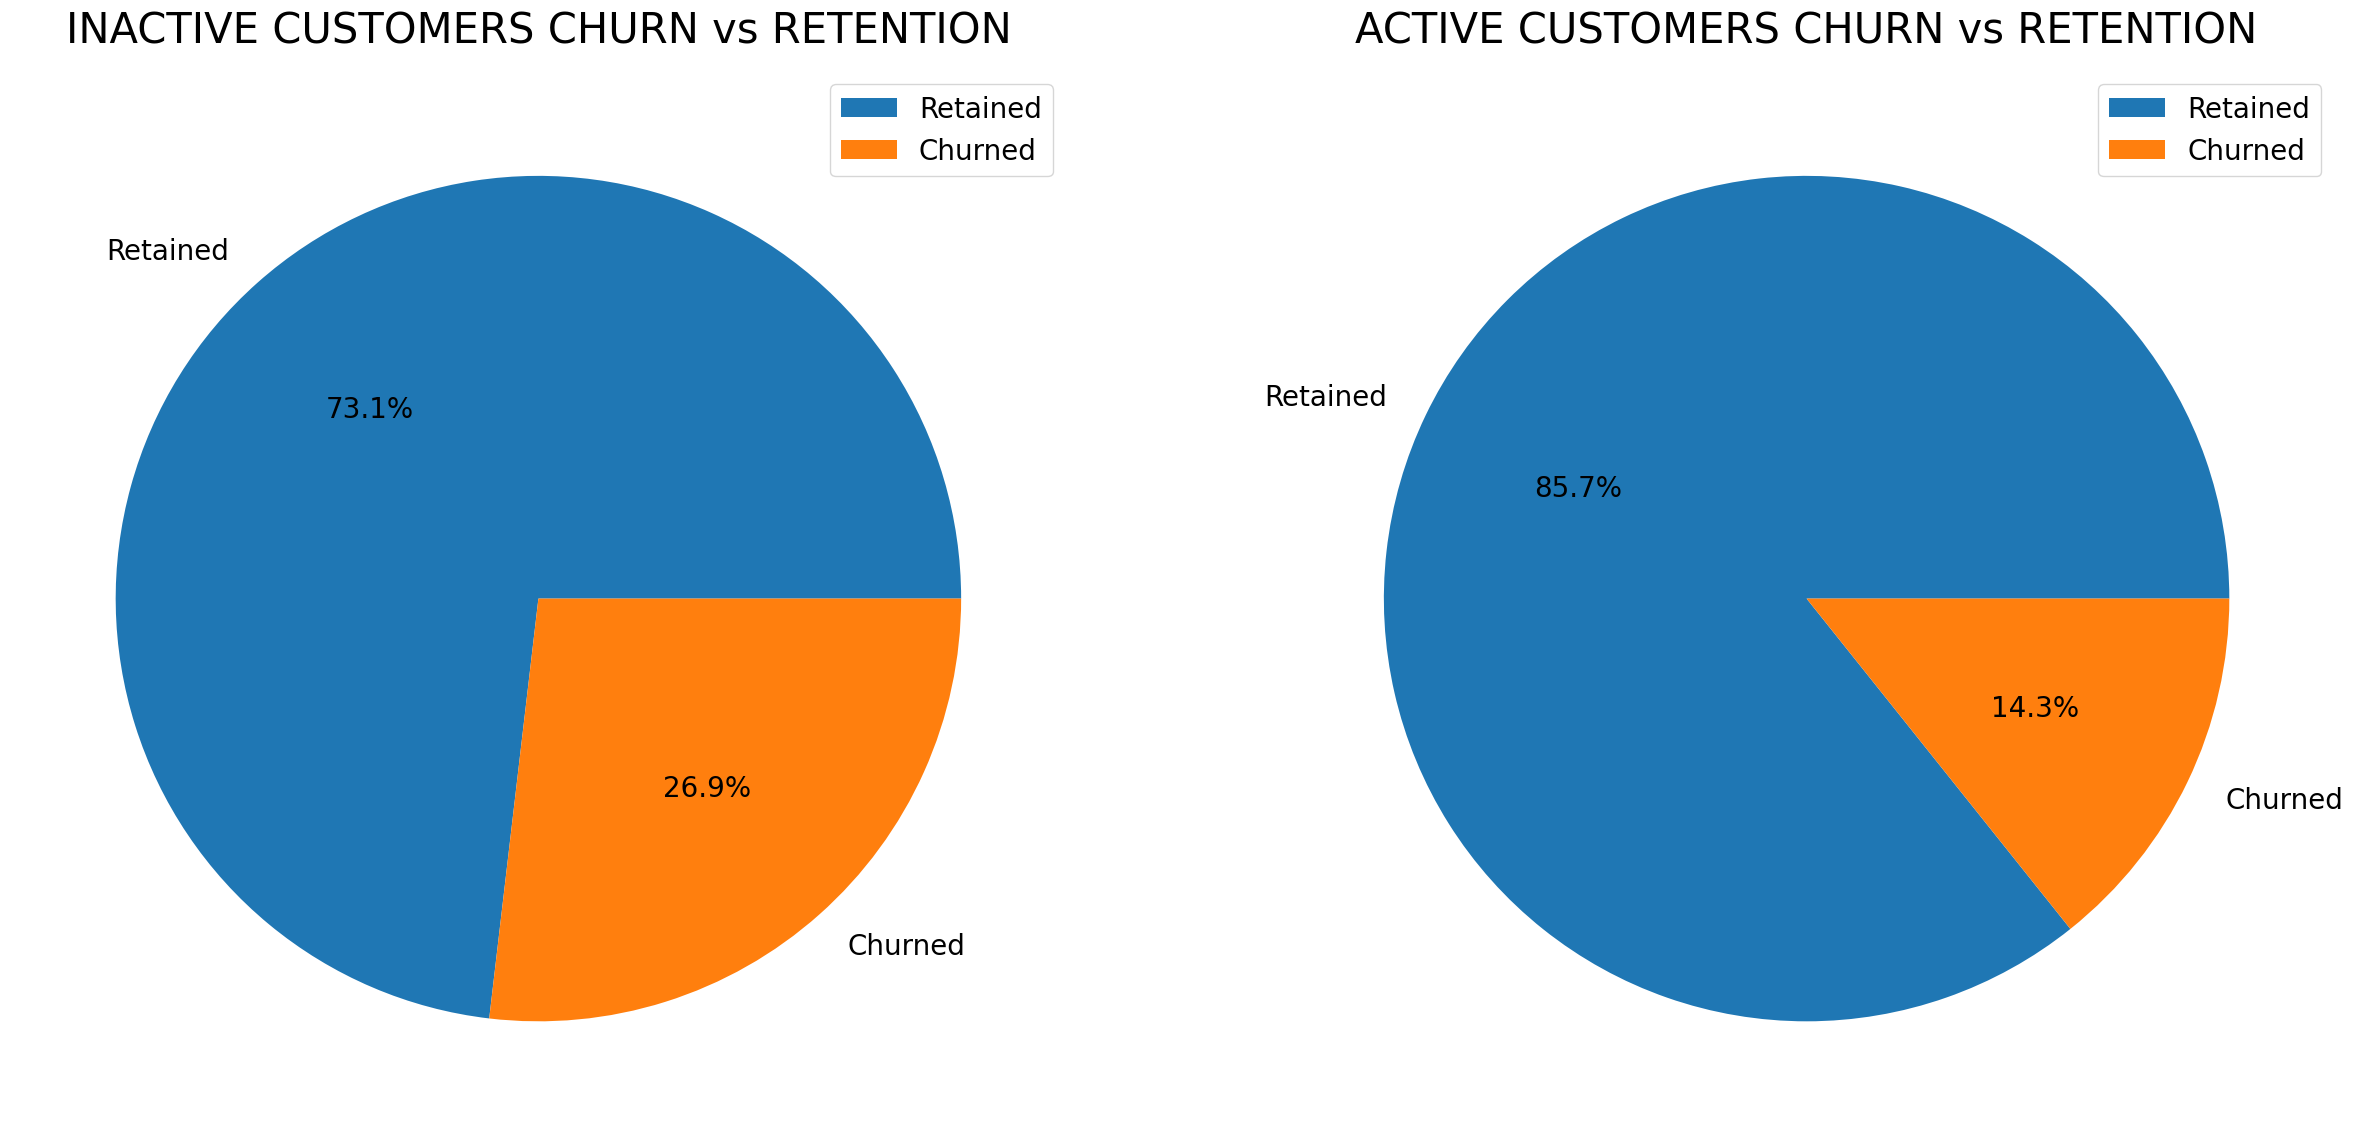

In [269]:
fig, ax = plt.subplots(1,2,figsize=(30,30))

ax[0].pie(acn['count'],labels=acn['Exited'],autopct='%1.1f%%',textprops={'fontsize': 20})
ax[0].set_title('INACTIVE CUSTOMERS CHURN vs RETENTION',fontsize=30, pad=20)
ax[0].legend(acn['Exited'],prop={'size': 20})

ax[1].pie(acy['count'],labels=acy['Exited'],autopct='%1.1f%%',textprops={'fontsize': 20})
ax[1].set_title('ACTIVE CUSTOMERS CHURN vs RETENTION',fontsize=30, pad=20)
ax[1].legend(acy['Exited'],prop={'size': 20})

plt.show()

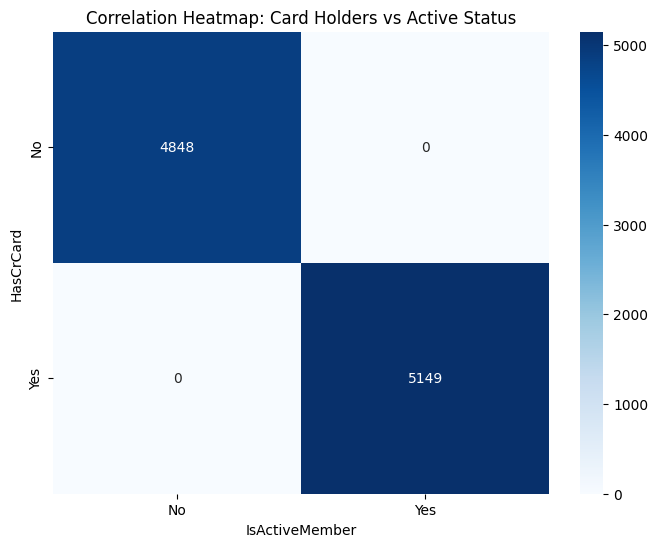

In [271]:
plt.figure(figsize=(8, 6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Correlation Heatmap: Card Holders vs Active Status')
plt.show()

**5. PRODUCT USAGE**
* Customers with 2 products are the most stable segment
* Customers with only 1 product show higher churn (27.7%)
* 3–4 product churn is extremely high but segment size is very small, so limited business impact

***RECOMMENDATION:***
* Encourage cross-selling to move customers from 1 to 2 products
* Check if churn happens after specific product combinations
* Improve post-sale engagement instead of just cross-selling

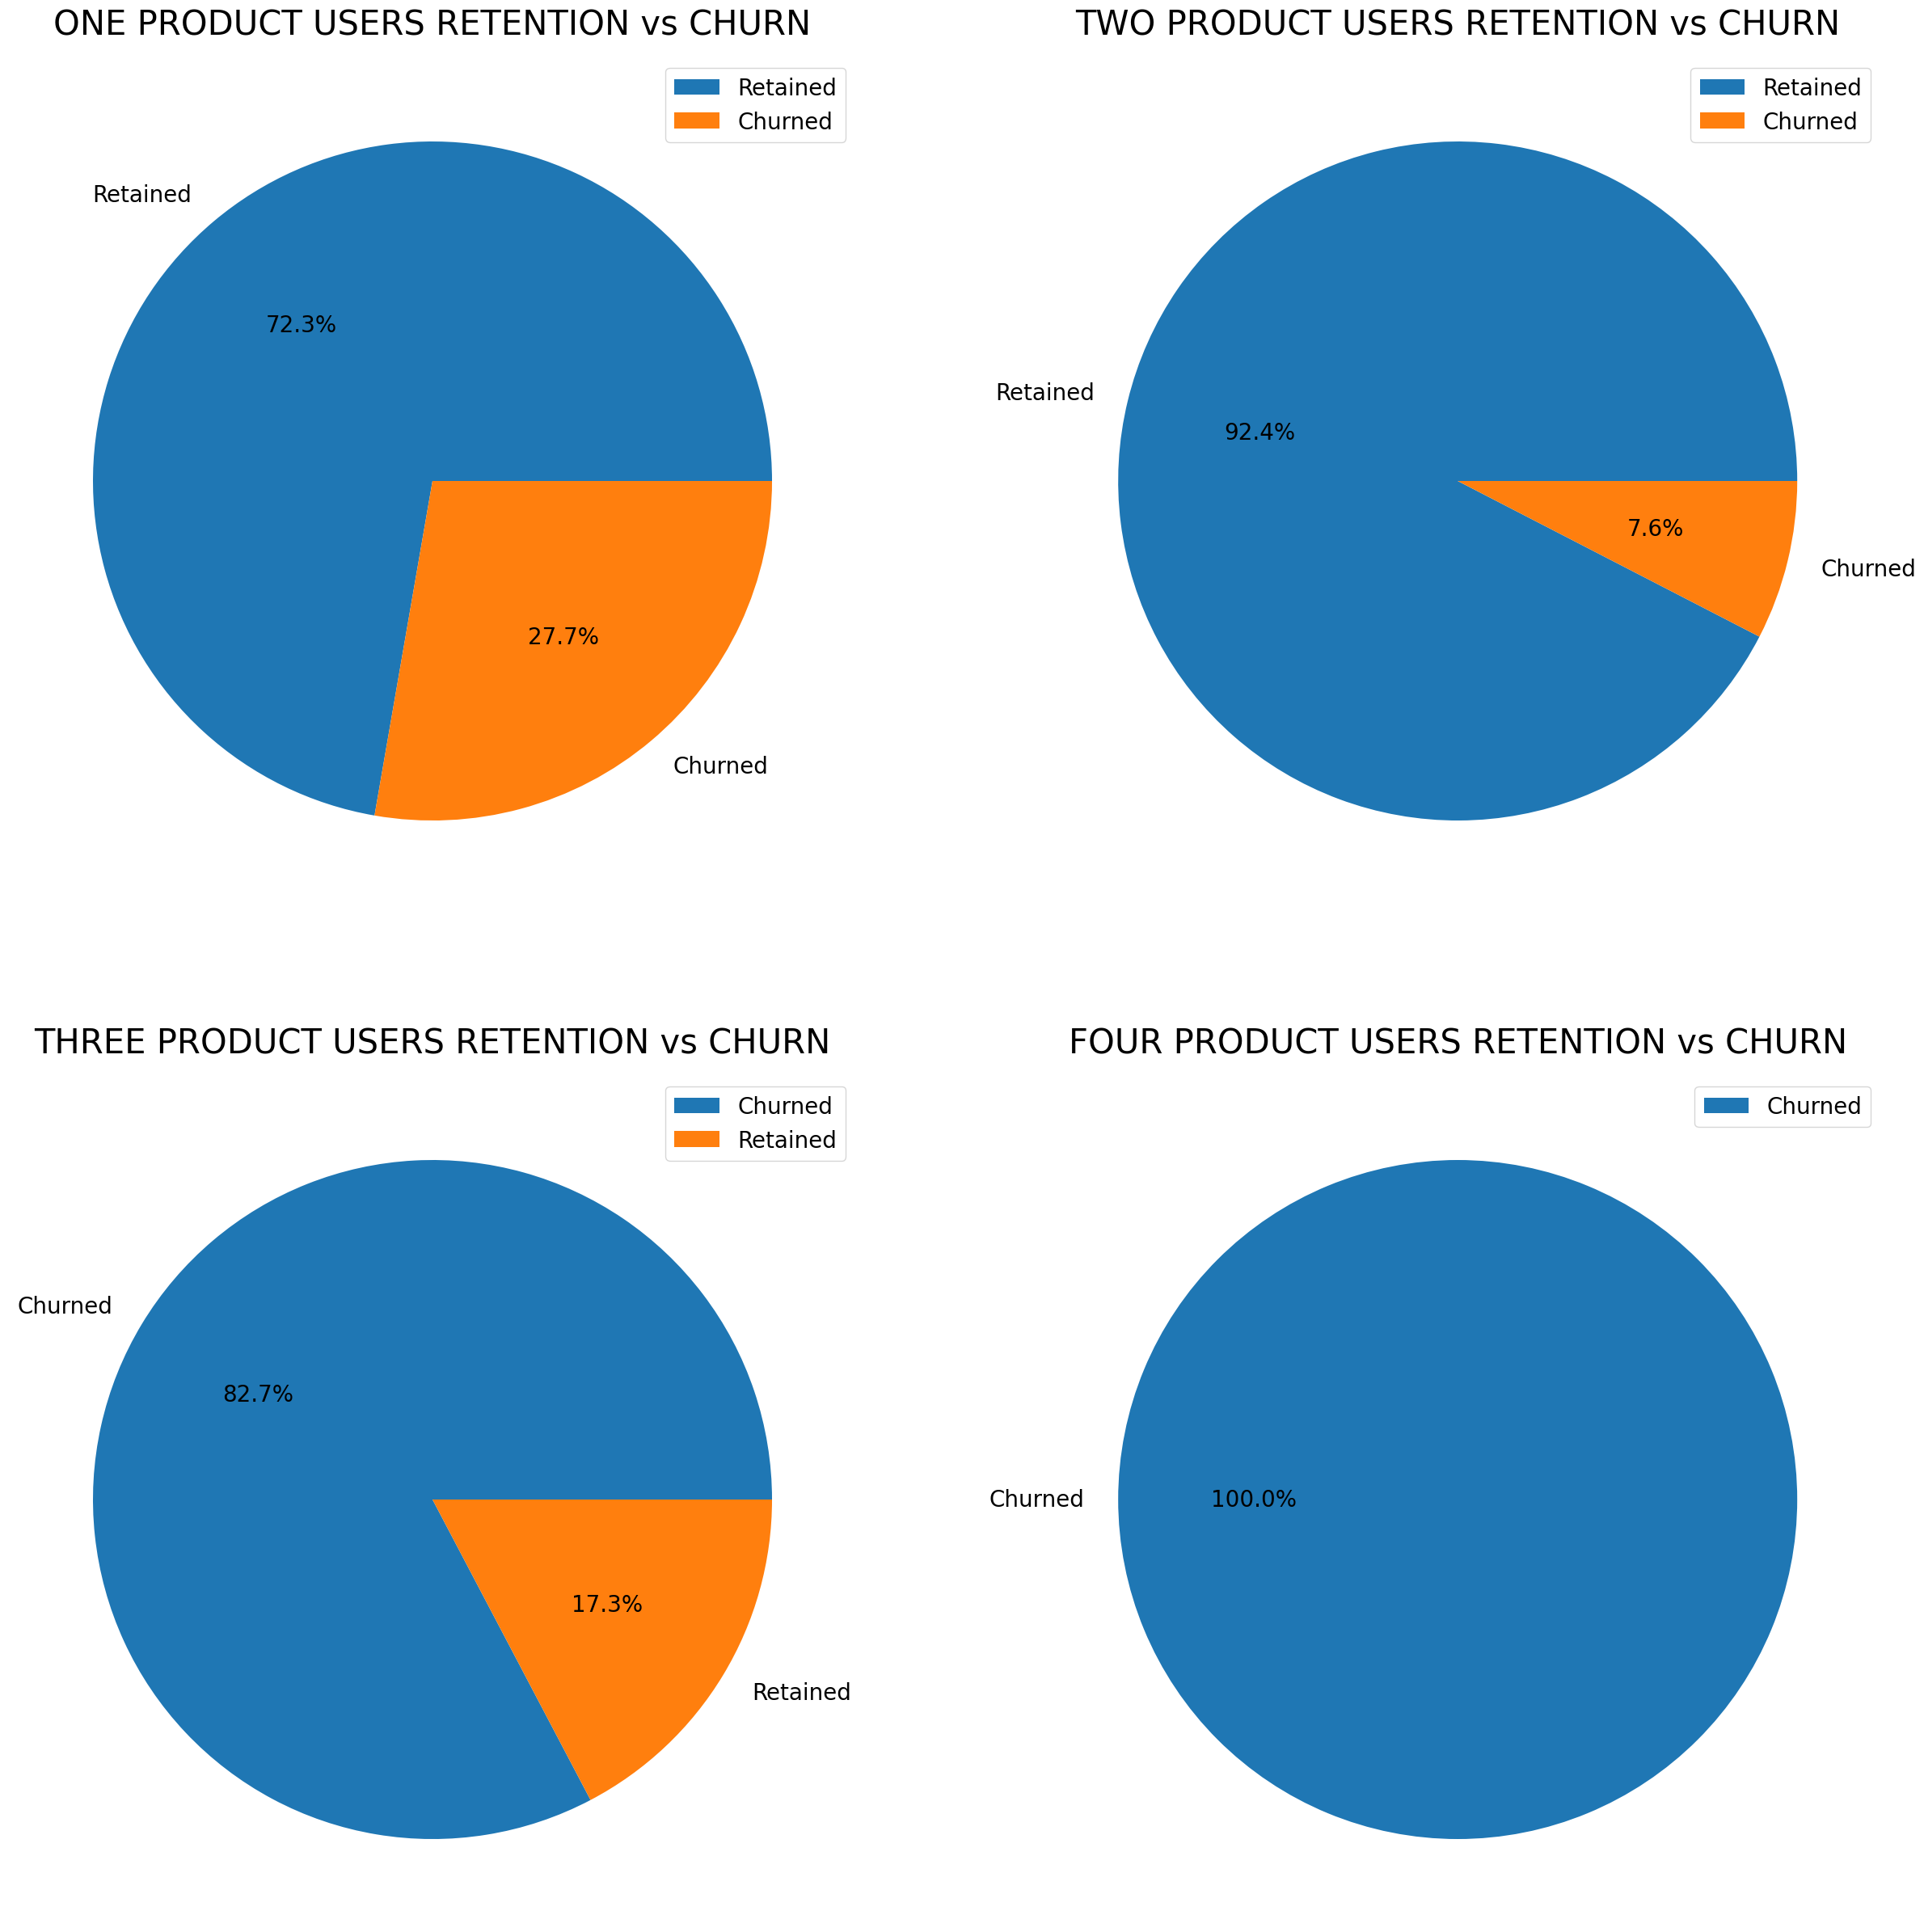

In [258]:
fig, ax = plt.subplots(2,2,figsize=(30,30))

ax[0,0].pie(nop1['Percentage'],labels=nop1['Exited'],autopct='%1.1f%%',textprops={'fontsize': 20})
ax[0,0].set_title('ONE PRODUCT USERS RETENTION vs CHURN',fontsize=30, pad=20)
ax[0,0].legend(nop1['Exited'],prop={'size': 20})

ax[0,1].pie(nop2['Percentage'],labels=nop2['Exited'],autopct='%1.1f%%',textprops={'fontsize': 20})
ax[0,1].set_title('TWO PRODUCT USERS RETENTION vs CHURN',fontsize=30, pad=20)
ax[0,1].legend(nop2['Exited'],prop={'size': 20})

ax[1,0].pie(nop3['Percentage'],labels=nop3['Exited'],autopct='%1.1f%%',textprops={'fontsize': 20})
ax[1,0].set_title('THREE PRODUCT USERS RETENTION vs CHURN',fontsize=30, pad=20)
ax[1,0].legend(nop3['Exited'],prop={'size': 20})

ax[1,1].pie(nop4['Percentage'],labels=nop4['Exited'],autopct='%1.1f%%',textprops={'fontsize': 20})
ax[1,1].set_title('FOUR PRODUCT USERS RETENTION vs CHURN',fontsize=30, pad=20)
ax[1,1].legend(nop4['Exited'],prop={'size': 20})

plt.show()

In [259]:
fig = px.bar(nopc,x='NumOfProducts',y='count',title='PRODUCT USERS',text_auto='.1f')
fig.show()

**6. GENDER-BASED CHURN DIFFERENCE**
* Female customers churn more (25%) compared to males (16.45%)

***RECOMMENDATION:***
* Investigate possible differences in service experience or product suitability across genders

In [260]:
fig = px.bar(gef,x='Exited',y='Percentage',title='FEMALE CUSTOMERS CHURN vs RETENTION RATE',text_auto='.1f')
fig.show()

**7. HIGH VALUE GERMAN CUSTOMERS**
* The high churn rate among German customers is particularly concerning because they represent the most valuable segment of the customer base as high-balance account holders.
* 78.3% of German accounts have high balance. And they do not hold any zero balance accounts.

***RECOMMENDATION:***
* Investigate service quality and competition in that region
* Design region-specific retention strategies instead of global ones

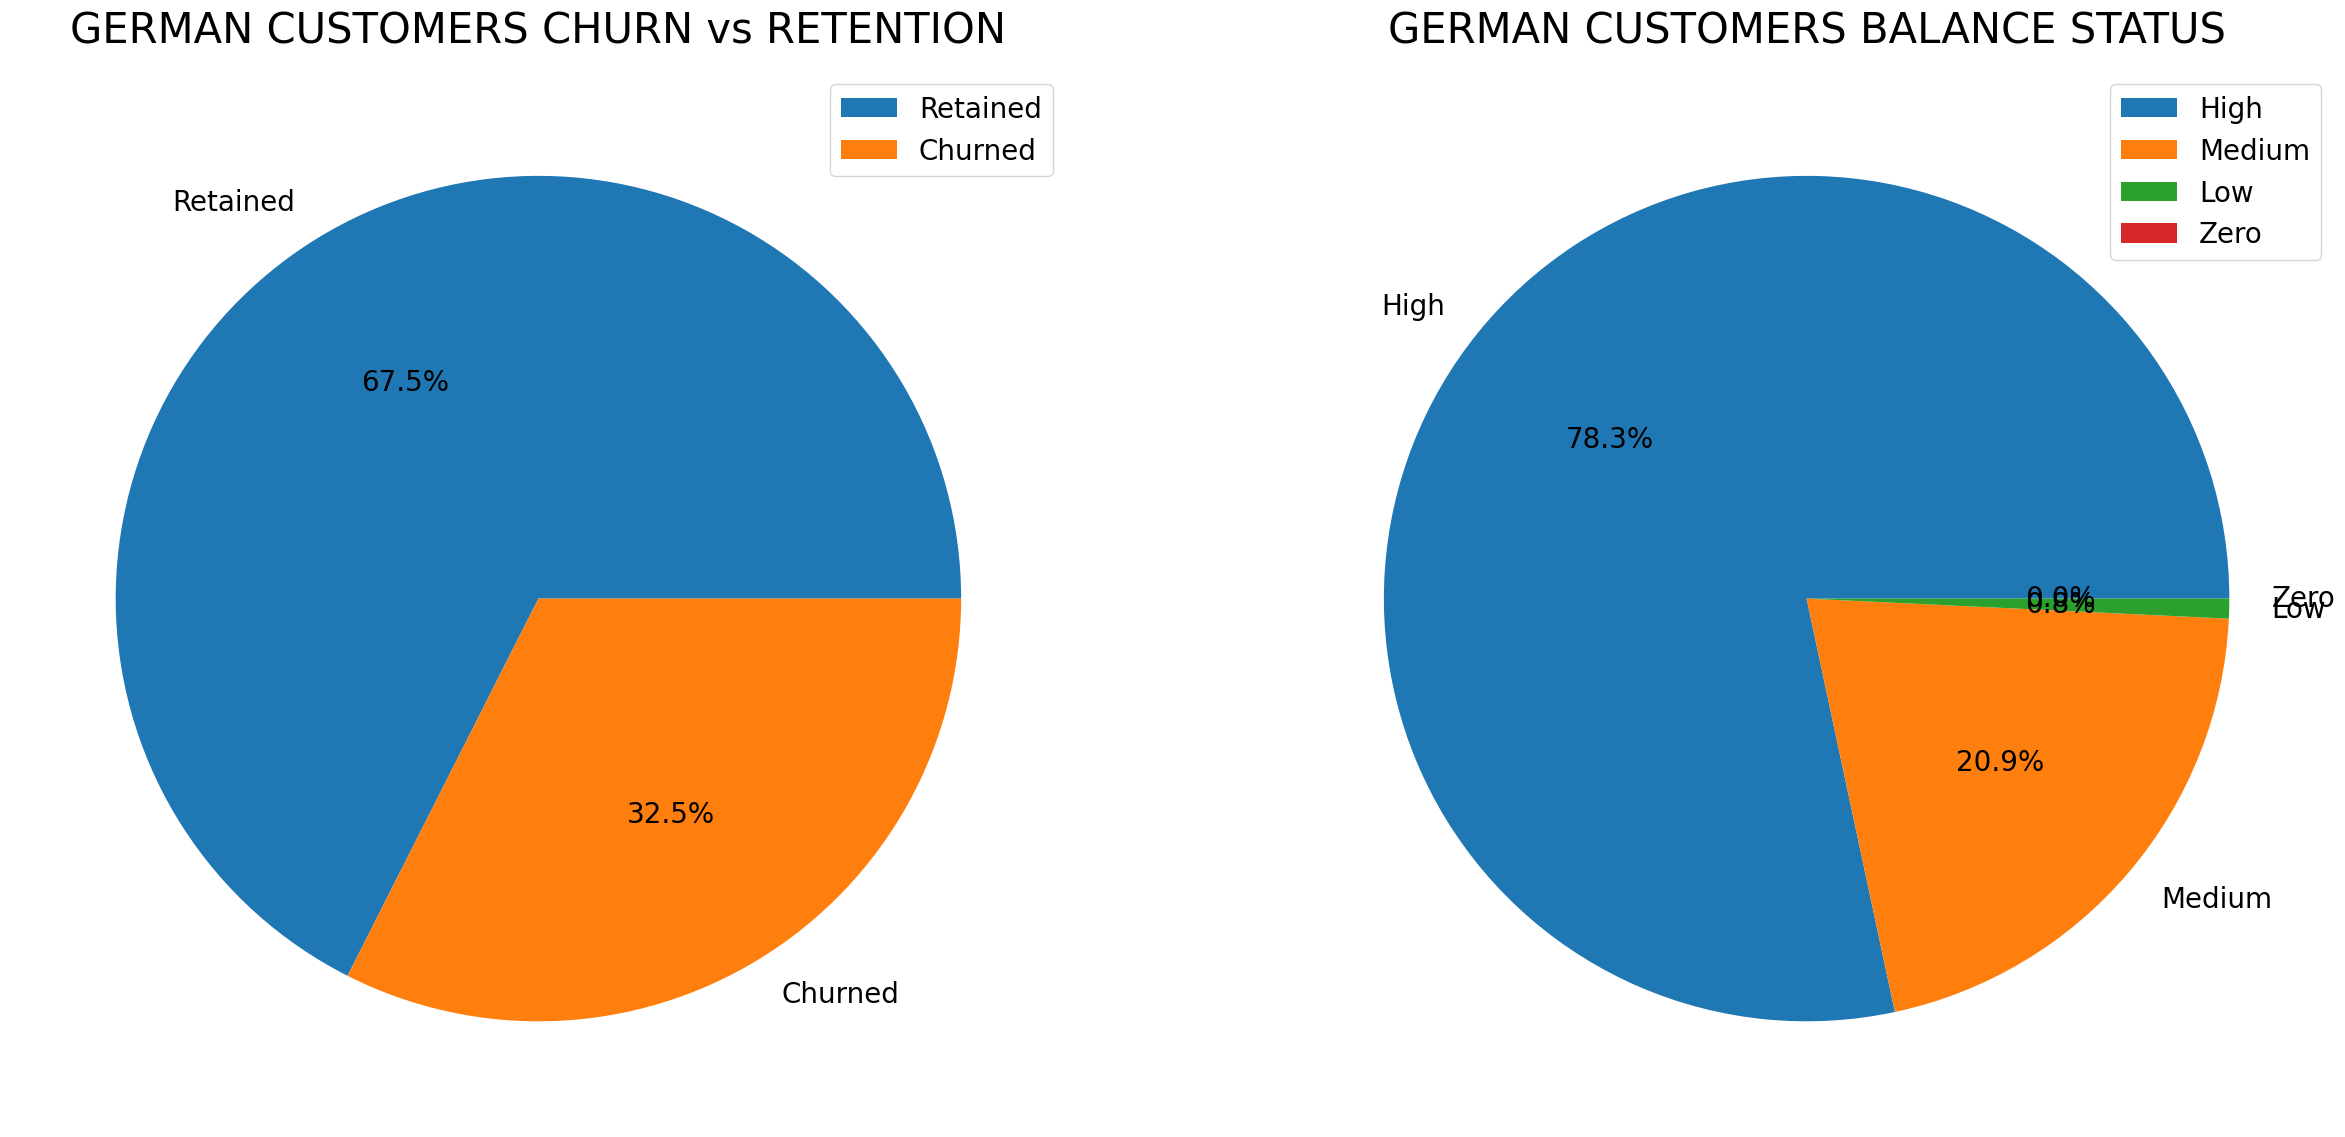

In [261]:
fig, ax = plt.subplots(1,2,figsize=(30,30))

ax[0].pie(gce['Percentage'],labels=gce['Exited'],autopct='%1.1f%%',textprops={'fontsize': 20})
ax[0].set_title('GERMAN CUSTOMERS CHURN vs RETENTION',fontsize=30, pad=20)
ax[0].legend(acn['Exited'],prop={'size': 20})

ax[1].pie(gbc['Percentage'],labels=gbc['BalanceStatus'],autopct='%1.1f%%',textprops={'fontsize': 20})
ax[1].set_title('GERMAN CUSTOMERS BALANCE STATUS',fontsize=30, pad=20)
ax[1].legend(gbc['BalanceStatus'],prop={'size': 20})

plt.show()

**8. EARLY-AGE ONBOARDING DRIVES STRONG RETENTION**
* Customers who joined as minors show very low churn (7.4%) vs overall 20.37%.

***RECOMMENDATION:***
* Invest in acquiring younger customers
* Design long-term engagement strategies to grow their value over time

In [262]:
fig = px.bar(ua,x='Exited',y='Percentage',title='MINOR  CHURN RATE',text_auto='.1f')
fig.show()